In [1]:
# ========================================
# CUSTOM CNN FOR CHEST X-RAY PNEUMONIA
# ========================================

import os
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")

# =========================
# 1. Reproducibility + safe device setup
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_safe_device():
    if torch.cuda.is_available():
        try:
            _ = torch.tensor([1.0]).to("cuda")
            torch.cuda.manual_seed_all(SEED)
            return torch.device("cuda")
        except Exception:
            pass
    return torch.device("cpu")

device = get_safe_device()
print("Using device:", device)

# =========================
# 2. Dataset path
# =========================
DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")


Using device: cuda


In [2]:
# =========================
# 3. Load file paths
# =========================
def collect_image_paths_and_labels(root_dir):
    data = []
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    for cls_name in classes:
        cls_path = os.path.join(root_dir, cls_name)
        for file_name in os.listdir(cls_path):
            if file_name.lower().endswith(IMG_EXTENSIONS):
                file_path = os.path.join(cls_path, file_name)
                data.append([file_path, cls_name, class_to_idx[cls_name]])

    df = pd.DataFrame(data, columns=["file_path", "label_name", "label"])
    return df, class_to_idx

train_df, class_to_idx = collect_image_paths_and_labels(TRAIN_DIR)
val_df, _ = collect_image_paths_and_labels(VAL_DIR)
test_df, _ = collect_image_paths_and_labels(TEST_DIR)

idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print("\nClass mapping:", class_to_idx)
print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)



Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train shape: (5216, 3)
Val shape  : (16, 3)
Test shape : (624, 3)


In [3]:
# =========================
# 4. Reset indexes
# =========================
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nDataset sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


Dataset sizes:
Train: 5216
Val  : 16
Test : 624



Train distribution:
label_name
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

Validation distribution:
label_name
NORMAL       8
PNEUMONIA    8
Name: count, dtype: int64

Test distribution:
label_name
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


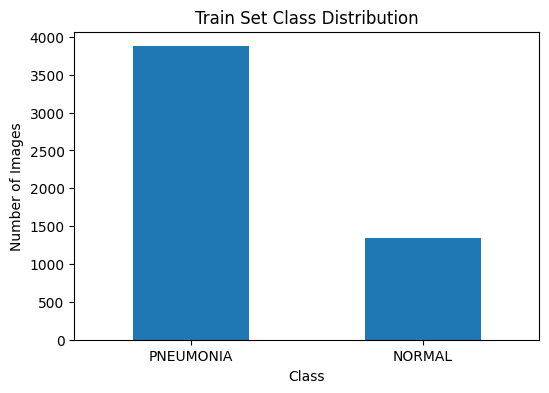

Imbalance ratio (train): 2.89


In [4]:
# =========================
# 5. Show class distribution
# =========================
def show_distribution(df, name):
    counts = df["label_name"].value_counts()
    print(f"\n{name} distribution:")
    print(counts)
    return counts

train_counts = show_distribution(train_df, "Train")
val_counts = show_distribution(val_df, "Validation")
test_counts = show_distribution(test_df, "Test")

plt.figure(figsize=(6, 4))
train_counts.plot(kind="bar")
plt.title("Train Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Imbalance ratio (train): {imbalance_ratio:.2f}")